In [2]:
from tkinter import *
import mysql.connector as m
from tkinter import messagebox
from tkinter import ttk
import pandas as pd
from matplotlib import pyplot as plt

ntxt=ntxt1=ntxt2=ntxt3=ntxt4=curs=user=pas=None
def on_close():
    conf=messagebox.askquestion("Confirmation", "Do you want to exit?")
    if conf=='yes':
        msc.destroy()            
def cl():
    try:
        top.destroy()
    except:
        pass          
def save():
    mycon=m.connect(host='localhost',user=user,db='test',password=pas,auth_plugin='mysql_native_password')
    curs=mycon.cursor()
    n=ntxt.get()
    n1=ntxt1.get()
    n2=ntxt2.get()
    n3=ntxt3.get()
    n4=ntxt4.get()
    q="INSERT INTO xyz (id,name,mobile,email,city) VALUES (%s, %s, %s, %s, %s)"
    t=(n,n1,n2,n3,n4)
    curs.execute(q,t)
    mycon.commit()
    messagebox.showinfo("Data Saved", "Data inserted successfully.")
    ntxt.delete(0, END)
    ntxt1.delete(0, END)
    ntxt2.delete(0, END)
    ntxt3.delete(0, END)
    ntxt4.delete(0, END)
    table.insert("",END,values=t)
    mycon.close()
    
    
def ent():
    global ntxt,ntxt1,ntxt2,ntxt3,ntxt4,curs,mycon,user,pas,top,table
    user = nusen.get()
    pas = npasn.get()
    try:
        if user and pas:
            mycon=m.connect(host='localhost',user=user,db='test',password=pas,auth_plugin='mysql_native_password')
            curs=mycon.cursor()
            top=Toplevel(msc)   
            top.title('Detail Page')
            top.geometry('605x500')
            top.resizable(0,0)
            nlbl=Label(top,text='Id')
            nlbl.place(x=10,y=10)
            ntxt=Entry(top)
            ntxt.place(x=70,y=10) 
            nage=Label(top,text='Name')
            nage.place(x=10,y=50)
            ntxt1=Entry(top)
            ntxt1.place(x=70,y=50)
            npl=Label(top,text='Mobile')
            npl.place(x=10,y=90)
            ntxt2=Entry(top)
            ntxt2.place(x=70,y=90)
            nocc=Label(top,text='Email')
            nocc.place(x=270,y=10)
            ntxt3=Entry(top)
            ntxt3.place(x=330,y=10)
            nmob=Label(top,text='City')
            nmob.place(x=270,y=50)
            ntxt4=Entry(top)
            ntxt4.place(x=330,y=50)
            nbu=Button(top,text='Save',command=save)
            nbu.place(x=340,y=90)
            top.bind("<Return>", lambda event: save())
            nbu2=Button(top,text='Cancel',command=cl)
            nbu2.place(x=390,y=90)
            ndif=Label(top,text='======================================================================================================')
            ndif.place(x=0,y=120)
            table=ttk.Treeview(top,columns=('Id','Name','Mobile','Email','City'),show='headings')
            table.column("Id", width=80)
            table.column("Name", width=100)
            table.column("Mobile", width=120)
            table.column("Email", width=193)
            table.column("City", width=110)
            table.heading('Id',text='Id',anchor='w')
            table.heading('Name',text='Name',anchor='w')
            table.heading('Mobile',text='Mobile',anchor='w')
            table.heading('Email',text='E-mail',anchor='w')
            table.heading('City',text='City',anchor='w')
            table.place(x=0,y=150,height=350)
            q3='select * from xyz'
            curs.execute(q3)
            for r in curs.fetchall():
                table.insert("",END,values=r)
    except:
       messagebox.showerror("Error", "Insert correct username/password.")


msc = Tk()
msc.title('DB Login Page')
msc.geometry('300x300')
msc.resizable(0,0)


msc.protocol('WM_DELETE_WINDOW',on_close)


nuse=Label(msc,text="Username-")
nuse.place(x=30,y=80)
nusen=Entry(msc)
nusen.place(x=100,y=80)


npas=Label(msc,text="Password-")
npas.place(x=30,y=180)
npasn=Entry(msc,show='*')
npasn.place(x=100,y=180)


nent=Button(msc,text="Enter",command=ent)
nent.place(x=100,y=250)
msc.bind("<Return>", lambda event: ent())


msc.mainloop()

In [41]:
df = pd.read_sql('select * from xyz',con=mycon)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25572\3830702392.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('select * from xyz',con=mycon)


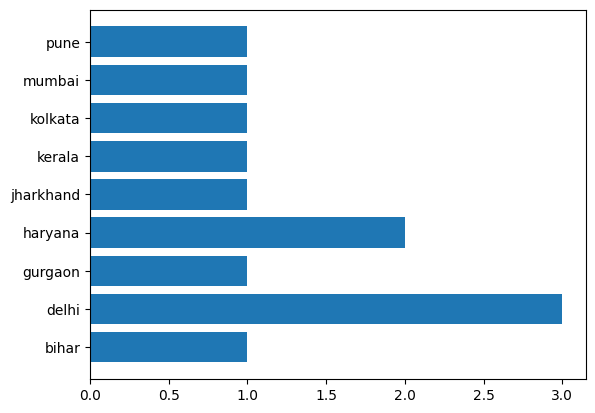

In [37]:
#for analysis
grp=df.groupby('city')['name'].count()
plt.barh(y=grp.index,width=grp.values)
plt.show()